# 39.1 · Contrastive views and SimCLR

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain contrastive views and simclr using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[26 · Transfer Learning](../../26-transfer-learning/README.md), [38 · Attention Mechanisms](../../38-attention-mechanisms/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Self-supervised learning constructs a training signal from data itself. The goal is a useful representation, not merely a low pretext-task loss. Augmentations and objectives decide what information is preserved and what is deliberately ignored.

## 2. Intuition

Contrastive learning pulls representations of two augmented views of the same image together and distinguishes other examples. Normalization and temperature control similarity scores. The local SimCLR-style experiment forms paired views and computes a normalized temperature-scaled contrastive objective. Augmentations must preserve information needed for downstream tasks.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 39
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
\theta_{target}\leftarrow m\theta_{target}+(1-m)\theta_{online}
$$

m is the EMA momentum, θtarget the slow-moving parameters and θonline the current trained parameters. With values 1 and 3 and m=0.9, the target becomes 1.2.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
target, online, momentum = 1.0, 3.0, 0.9
updated_target = momentum * target + (1 - momentum) * online
assert np.isclose(updated_target, 1.2)
print(updated_target)

1.2


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

Three experiments isolate contrastive pair construction, EMA target consistency and masked reconstruction. They use small synthetic data and report local objectives, not large-scale representation benchmarks.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def self_supervision(lesson, seed, amount):
    configure(seed)
    x, _, _ = shape_data(48, seed=seed)
    if lesson == 2:
        model = Autoencoder()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
        losses = []
        mask = torch.rand_like(x) > 0.4
        for _ in range(25):
            reconstructed, _, _ = model(x * mask)
            loss = ((reconstructed - x) ** 2 * (~mask)).sum() / (~mask).sum()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(float(loss.detach()))
        return Result(
            "39 · Masked-image reconstruction",
            {
                "Input": x[0, 0].numpy(),
                "Visible patches": (x * mask)[0, 0].numpy(),
                "Reconstruction": reconstructed[0, 0].detach().numpy(),
            },
            curves={"Masked MSE": losses},
            metrics={"mask_fraction": float((~mask).float().mean())},
        )
    encoder = nn.Sequential(nn.Flatten(), nn.Linear(24 * 24, 48), nn.ReLU(), nn.Linear(48, 16))
    optimizer = torch.optim.Adam(encoder.parameters(), lr=0.002)
    losses = []
    import copy

    target = copy.deepcopy(encoder)
    for parameter in target.parameters():
        parameter.requires_grad = False
    for _ in range(30):
        a = (x + 0.08 * torch.randn_like(x)).clamp(0, 1)
        b = (x + 0.08 * torch.randn_like(x)).clamp(0, 1)
        za = F.normalize(encoder(a), dim=1)
        if lesson == 0:
            zb = F.normalize(encoder(b), dim=1)
            z = torch.cat([za, zb])
            logits = z @ z.T / (0.2 * amount)
            logits.fill_diagonal_(-1e9)
            labels = (torch.arange(96) + 48) % 96
            loss = F.cross_entropy(logits, labels)
        else:
            with torch.no_grad():
                zb = F.normalize(target(b), dim=1)
            loss = 2 - 2 * (za * zb).sum(1).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if lesson == 1:
            with torch.no_grad():
                for dest, source in zip(target.parameters(), encoder.parameters(), strict=True):
                    dest.mul_(0.95).add_(source, alpha=0.05)
        losses.append(float(loss.detach()))
    with torch.no_grad():
        embedding = encoder(x)
    return Result(
        "39 · Contrastive views and stop-gradient EMA",
        {
            "Input": x[0, 0].numpy(),
            "Noisy view": a[0, 0].numpy(),
            "Embedding dimensions": embedding.numpy(),
        },
        curves={"Training objective": losses},
        metrics={
            "embedding_mean_std": float(embedding.std(0).mean()),
            "method": "NT-Xent" if lesson == 0 else "minimal EMA consistency",
        },
        notes="The EMA consistency example omits BYOL’s predictor and full augmentation recipe; monitor collapse. It is an ingredient study, not a faithful BYOL reproduction.",
    )

{
  "embedding_mean_std": 0.17155075073242188,
  "method": "NT-Xent"
}
The EMA consistency example omits BYOL’s predictor and full augmentation recipe; monitor collapse. It is an ingredient study, not a faithful BYOL reproduction.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/models.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.models import Autoencoder

display(Code(inspect.getsource(Autoencoder), language="python"))

class Autoencoder(nn.Module):
    def __init__(self, variational=False):
        super().__init__()
        self.variational = variational
        self.encoder = nn.Sequential(nn.Linear(24 * 24, 64), nn.ReLU())
        self.mu = nn.Linear(64, 12)
        self.logvar = nn.Linear(64, 12)
        self.decoder = nn.Sequential(
            nn.Linear(12, 64), nn.ReLU(), nn.Linear(64, 24 * 24), nn.Sigmoid()
        )

    def forward(self, x):
        hidden = self.encoder(x.flatten(1))
        mu = self.mu(hidden)
        logvar = self.logvar(hidden).clamp(-8, 8)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar) if self.variational else mu
        reconstruction = self.decoder(z).reshape(-1, 1, 24, 24)
        return reconstruction, mu, logvar

## 8. Experiment

Remove an augmentation and measure downstream probe performance, not only training loss. Check embedding variance for collapse.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "embedding_mean_std": 0.17155075073242188,
    "method": "NT-Xent"
  },
  "second_seed": {
    "embedding_mean_std": 0.15184584259986877,
    "method": "NT-Xent"
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

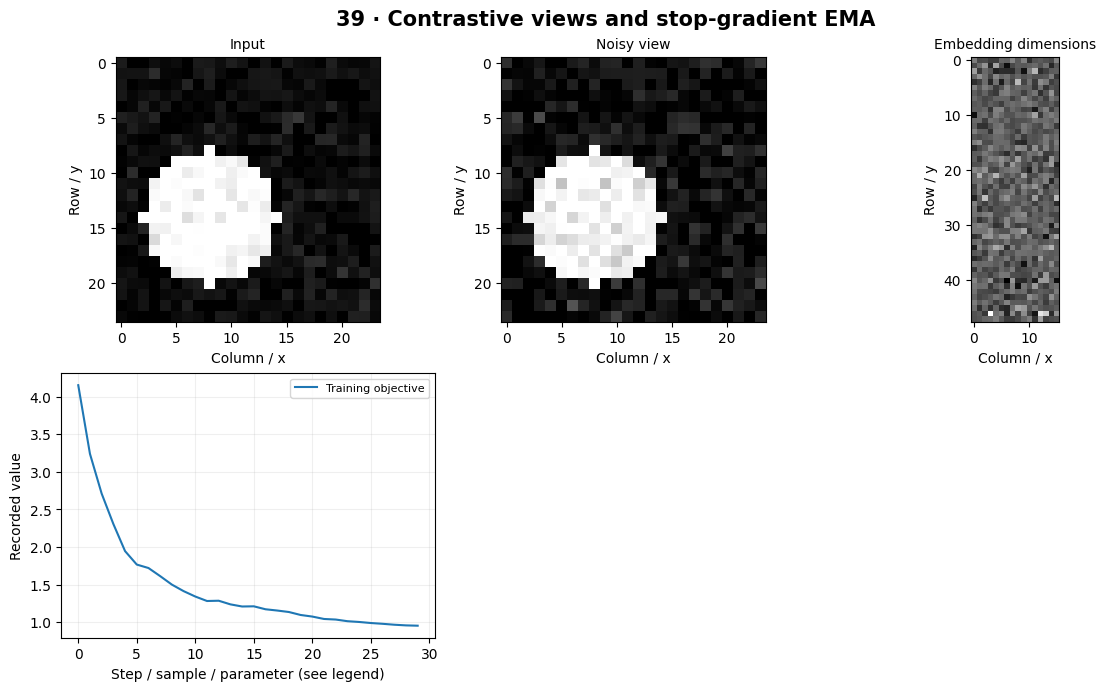

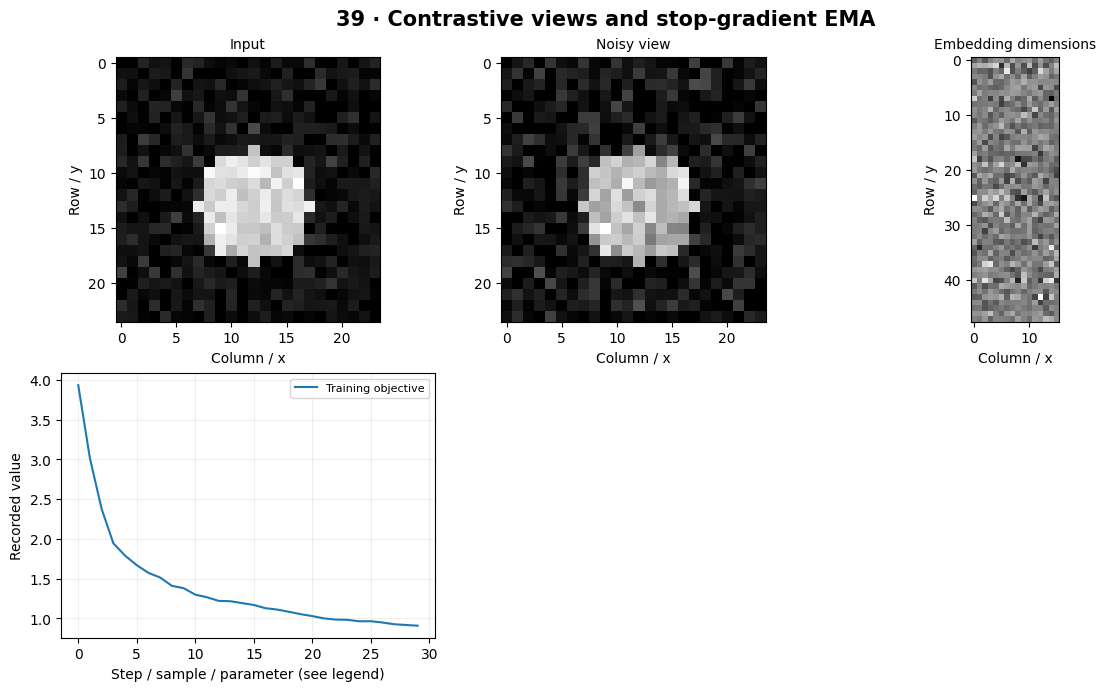

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Self-Supervised Representation Lab**. Compare representations with fixed evaluation protocols. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Two crops can remove the object and cease to be meaningful positive pairs. EMA consistency without the full method can collapse.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Remove an augmentation and measure downstream probe performance, not only training loss. Check embedding variance for collapse.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Pretrain a representation without labels and compare a frozen linear probe with a randomly initialized baseline on identical labeled splits.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Contrastive learning pulls representations of two augmented views of the same image together and distinguishes other examples. Normalization and temperature control similarity scores. The local SimCLR-style experiment forms paired views and computes a normalized temperature-scaled contrastive objective. Augmentations must preserve information needed for downstream tasks.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **EMA targets and BYOL ideas** in this chapter.

[Primary reference](https://arxiv.org/abs/2002.05709) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)